# Reptile — Omniglot 20-way 5-shot

Reptile meta-learning (Nichol et al., 2018) for 20-way 5-shot classification on Omniglot. 
Key implementation details:
- Adam inner-loop with `betas=(0.0, 0.999)` — momentum disabled to prevent state bleed across tasks
- `inner_steps` counts optimizer updates, not full passes over the support set
- Meta-LR linearly annealed from 0.2 to 0 over the full run
- Adam optimizer state persisted across meta-iterations during training
- Checkpoint saved every `block_size` iterations; rerun the training cell to resume

## 1. Imports, Seed & Device

In [1]:
import os
import random
import copy
import shutil
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

print("PyTorch:", torch.__version__)


PyTorch: 2.10.0+cu128


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)


Device: cuda


In [3]:

if os.path.exists("/kaggle/working"):
    OUTPUT_DIR = Path("/kaggle/working")
else:
    OUTPUT_DIR = Path("./outputs")

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "reptile_o205_paper_aligned"
CKPT_PATH = CHECKPOINT_DIR / f"{RUN_NAME}_ckpt.pt"
FINAL_PATH = OUTPUT_DIR / f"{RUN_NAME}_final_with_history.pt"

print("Output dir:", OUTPUT_DIR)
print("Checkpoint path:", CKPT_PATH)
print("Final save path:", FINAL_PATH)


Output dir: /kaggle/working
Checkpoint path: /kaggle/working/checkpoints/reptile_o205_paper_aligned_ckpt.pt
Final save path: /kaggle/working/reptile_o205_paper_aligned_final_with_history.pt


In [4]:
UPLOADED_CKPT = ""
if UPLOADED_CKPT and os.path.exists(UPLOADED_CKPT) and not CKPT_PATH.exists():
    shutil.copy(UPLOADED_CKPT, CKPT_PATH)
    print("Copied uploaded checkpoint to:", CKPT_PATH)
else:
    print("No uploaded checkpoint copied.")


No uploaded checkpoint copied.


## 2. Dataset Paths & Preprocessing

In [5]:
def find_omniglot_roots():
    candidates = [

        ("/kaggle/input/datasets/watesoyan/omniglot/images_background",
         "/kaggle/input/datasets/watesoyan/omniglot/images_evaluation"),


        ("/kaggle/input/omniglot/images_background",
         "/kaggle/input/omniglot/images_evaluation"),
        ("/kaggle/input/omniglot-py/images_background",
         "/kaggle/input/omniglot-py/images_evaluation"),

        ("./omniglot/images_background",
         "./omniglot/images_evaluation"),
        ("./images_background",
         "./images_evaluation"),
    ]

    for train_root, test_root in candidates:
        if os.path.isdir(train_root) and os.path.isdir(test_root):
            return train_root, test_root

    raise FileNotFoundError(
        "Could not find Omniglot. Set train_root and test_root manually in the next cell."
    )

train_root, test_root = find_omniglot_roots()

print("train_root:", train_root)
print("test_root :", test_root)


train_root: /kaggle/input/datasets/watesoyan/omniglot/images_background
test_root : /kaggle/input/datasets/watesoyan/omniglot/images_evaluation


In [6]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

In [7]:
def count_images(root_dir):
    total = 0
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue
        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue
            total += sum(
                1 for name in os.listdir(character_path)
                if name.lower().endswith((".png", ".jpg", ".jpeg"))
            )
    return total

def count_classes(root_dir):
    total = 0
    for alphabet in os.listdir(root_dir):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue
        for character in os.listdir(alphabet_path):
            character_path = os.path.join(alphabet_path, character)
            if os.path.isdir(character_path):
                total += 1
    return total

print("Background images:", count_images(train_root))
print("Evaluation images:", count_images(test_root))
print("Background classes:", count_classes(train_root))
print("Evaluation classes:", count_classes(test_root))


Background images: 19280
Evaluation images: 13180
Background classes: 964
Evaluation classes: 659


## 3. Class Dictionaries & Task Samplers

In [8]:
def build_class_dict(root_dir, transform, prefix=""):
    class_dict = {}

    for alphabet in sorted(os.listdir(root_dir)):
        alphabet_path = os.path.join(root_dir, alphabet)
        if not os.path.isdir(alphabet_path):
            continue

        for character in sorted(os.listdir(alphabet_path)):
            character_path = os.path.join(alphabet_path, character)
            if not os.path.isdir(character_path):
                continue

            images = []
            for img_name in sorted(os.listdir(character_path)):
                img_path = os.path.join(character_path, img_name)
                if not os.path.isfile(img_path):
                    continue
                if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                image = Image.open(img_path).convert("L")
                image_tensor = transform(image)
                images.append(image_tensor)

            if len(images) > 0:
                class_id = f"{prefix}{alphabet}/{character}"
                class_dict[class_id] = images

    return class_dict


train_classes_full = build_class_dict(train_root, transform, prefix="bg/")
test_classes = build_class_dict(test_root, transform, prefix="eval/")

all_train_class_ids = list(train_classes_full.keys())
random.seed(42)
random.shuffle(all_train_class_ids)

val_fraction = 0.10
num_val = int(len(all_train_class_ids) * val_fraction)

val_class_ids = all_train_class_ids[:num_val]
train_class_ids = all_train_class_ids[num_val:]

train_classes = {cid: train_classes_full[cid] for cid in train_class_ids}
val_classes = {cid: train_classes_full[cid] for cid in val_class_ids}

print("Meta-train classes:", len(train_classes))
print("Meta-val classes  :", len(val_classes))
print("Meta-test classes :", len(test_classes))
print("Min images/class in train:", min(len(v) for v in train_classes.values()))
print("Min images/class in val  :", min(len(v) for v in val_classes.values()))
print("Min images/class in test :", min(len(v) for v in test_classes.values()))


Meta-train classes: 868
Meta-val classes  : 96
Meta-test classes : 659
Min images/class in train: 20
Min images/class in val  : 20
Min images/class in test : 20


In [9]:
class OmniglotTaskSampler:
    def __init__(self, class_to_images):
        self.class_to_images = class_to_images
        self.class_ids = list(class_to_images.keys())

    def sample_task(self, n_way=20, k_shot=10, q_query=5):
        if len(self.class_ids) < n_way:
            raise ValueError(
                f"Sampler has only {len(self.class_ids)} classes, but {n_way} were requested."
            )

        selected_classes = random.sample(self.class_ids, n_way)

        support_images, support_labels = [], []
        query_images, query_labels = [], []

        for local_label, class_id in enumerate(selected_classes):
            images = self.class_to_images[class_id]
            total_needed = k_shot + q_query

            if len(images) < total_needed:
                raise ValueError(
                    f"Class {class_id} has only {len(images)} images, "
                    f"but {total_needed} are required."
                )

            sampled_images = random.sample(images, total_needed)
            support_imgs = sampled_images[:k_shot]
            query_imgs = sampled_images[k_shot:]

            support_images.extend(support_imgs)
            query_images.extend(query_imgs)
            support_labels.extend([local_label] * k_shot)
            query_labels.extend([local_label] * q_query)

        support_x = torch.stack(support_images).float()
        support_y = torch.tensor(support_labels, dtype=torch.long)
        query_x = torch.stack(query_images).float()
        query_y = torch.tensor(query_labels, dtype=torch.long)

        return support_x, support_y, query_x, query_y


train_sampler = OmniglotTaskSampler(train_classes)
val_sampler = OmniglotTaskSampler(val_classes)
test_sampler = OmniglotTaskSampler(test_classes)

# quick sanity check
sx, sy, qx, qy = train_sampler.sample_task(n_way=20, k_shot=10, q_query=5)
print("support_x:", sx.shape, "support_y:", sy.shape)
print("query_x  :", qx.shape, "query_y  :", qy.shape)
print("labels:", sy.min().item(), "to", sy.max().item())


support_x: torch.Size([200, 1, 28, 28]) support_y: torch.Size([200])
query_x  : torch.Size([100, 1, 28, 28]) query_y  : torch.Size([100])
labels: 0 to 19


## 4. Model

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class OmniglotCNN(nn.Module):
    def __init__(self, n_way):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 64),
            ConvBlock(64, 64),
            ConvBlock(64, 64),
            ConvBlock(64, 64),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 2 * 2, n_way),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model_check = OmniglotCNN(n_way=20).to(device)
with torch.no_grad():
    y = model_check(torch.zeros(4, 1, 28, 28).to(device))
print("Model output shape:", y.shape)
del model_check


Model output shape: torch.Size([4, 20])


## 5. Adaptation & Evaluation

In [11]:
criterion = nn.NLLLoss()


def minibatch_indices(num_support, inner_batch_size, inner_steps, device):
    perm = torch.randperm(num_support, device=device)
    cursor = 0

    for _ in range(inner_steps):
        if cursor + inner_batch_size > num_support:
            perm = torch.randperm(num_support, device=device)
            cursor = 0

        batch_idx = perm[cursor:cursor + inner_batch_size]
        cursor += inner_batch_size
        yield batch_idx


def _optimizer_state_to_device(optimizer, device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def adapt_on_task(
    meta_model,
    support_x,
    support_y,
    inner_lr=0.0005,
    inner_steps=10,
    inner_batch_size=20,
    optimizer_state=None,
    return_optimizer_state=False
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)

    task_model = copy.deepcopy(meta_model)
    task_model.train()

    optimizer = torch.optim.Adam(
        task_model.parameters(),
        lr=inner_lr,
        betas=(0.0, 0.999)
    )


    if optimizer_state is not None:
        optimizer.load_state_dict(optimizer_state)
        _optimizer_state_to_device(optimizer, device)

    support_loss_value = None
    num_support = support_x.size(0)

    for batch_idx in minibatch_indices(
        num_support=num_support,
        inner_batch_size=inner_batch_size,
        inner_steps=inner_steps,
        device=device
    ):
        x_batch = support_x[batch_idx]
        y_batch = support_y[batch_idx]

        optimizer.zero_grad(set_to_none=True)
        log_probs = task_model(x_batch)
        loss = criterion(log_probs, y_batch)
        loss.backward()
        optimizer.step()

        support_loss_value = loss.item()

    if return_optimizer_state:
        return task_model, support_loss_value, optimizer.state_dict()

    return task_model, support_loss_value


In [12]:
def evaluate_task(
    meta_model,
    support_x,
    support_y,
    query_x,
    query_y,
    inner_lr=0.0005,
    inner_steps=50,
    inner_batch_size=10
):
    support_x = support_x.to(device)
    support_y = support_y.to(device)
    query_x = query_x.to(device)
    query_y = query_y.to(device)

    task_model, _ = adapt_on_task(
        meta_model=meta_model,
        support_x=support_x,
        support_y=support_y,
        inner_lr=inner_lr,
        inner_steps=inner_steps,
        inner_batch_size=inner_batch_size,
        optimizer_state=None,
        return_optimizer_state=False
    )

    task_model.eval()
    with torch.no_grad():
        query_log_probs = task_model(query_x)
        query_loss = criterion(query_log_probs, query_y).item()
        query_preds = query_log_probs.argmax(dim=1)
        query_acc = (query_preds == query_y).float().mean().item()

    return query_loss, query_acc


def evaluate_many_tasks(
    meta_model,
    test_sampler,
    num_tasks=100,
    n_way=20,
    k_shot=5,
    q_query=5,
    inner_lr=0.0005,
    inner_steps=50,
    inner_batch_size=10
):
    losses, accs = [], []

    for _ in range(num_tasks):
        support_x, support_y, query_x, query_y = test_sampler.sample_task(
            n_way=n_way,
            k_shot=k_shot,
            q_query=q_query
        )

        query_loss, query_acc = evaluate_task(
            meta_model=meta_model,
            support_x=support_x,
            support_y=support_y,
            query_x=query_x,
            query_y=query_y,
            inner_lr=inner_lr,
            inner_steps=inner_steps,
            inner_batch_size=inner_batch_size
        )

        losses.append(query_loss)
        accs.append(query_acc)

    return sum(losses) / len(losses), sum(accs) / len(accs)


## 6. Training Loop

In [ ]:
def reptile_train(
    meta_model,
    train_sampler,
    val_sampler=None,
    meta_iters=50000,
    tasks_per_meta_batch=5,
    n_way=20,
    train_k_shot=10,
    eval_k_shot=5,
    q_query=5,
    inner_lr=0.0005,
    inner_steps=10,
    inner_batch_size=20,
    meta_lr=0.2,
    meta_lr_final=0.0,
    anneal_meta_lr=True,
    eval_every=1000,
    eval_tasks=50,
    eval_inner_lr=None,
    eval_inner_steps=50,
    eval_inner_batch_size=10,
    device=device,
    ckpt_path=CKPT_PATH,
    block_size=50000
):
    
    meta_model = meta_model.to(device)

    if eval_inner_lr is None:
        eval_inner_lr = inner_lr

    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    start_iter = 1
    train_support_losses = []
    eval_query_losses = []
    eval_query_accuracies = []
    meta_lr_history = []

    best_eval_acc = -1.0
    best_model_state = copy.deepcopy(meta_model.state_dict())
    inner_optimizer_state = None

    if ckpt_path.exists():
        print(f"Loading checkpoint from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)

        meta_model.load_state_dict(ckpt["model_state"])
        start_iter = ckpt["meta_iter"] + 1

        train_support_losses = ckpt.get("train_support_losses", [])
        eval_query_losses = ckpt.get("eval_query_losses", [])
        eval_query_accuracies = ckpt.get("eval_query_accuracies", [])
        meta_lr_history = ckpt.get("meta_lr_history", [])

        best_eval_acc = ckpt.get("best_eval_acc", -1.0)
        best_model_state = ckpt.get("best_model_state", copy.deepcopy(meta_model.state_dict()))
        inner_optimizer_state = ckpt.get("inner_optimizer_state", None)

        print(f"Resuming from meta_iter = {start_iter}")

    if start_iter > meta_iters:
        print(f"Checkpoint already reached target meta_iters={meta_iters}.")
        meta_model.load_state_dict(best_model_state)
        return meta_model, {
            "train_support_losses": train_support_losses,
            "eval_query_losses": eval_query_losses,
            "eval_query_accuracies": eval_query_accuracies,
            "meta_lr_history": meta_lr_history,
            "best_eval_acc": best_eval_acc,
            "completed": True
        }

    for meta_iter in range(start_iter, meta_iters + 1):
        meta_model.train()

        if anneal_meta_lr:
            frac_done = (meta_iter - 1) / max(1, meta_iters - 1)
            current_meta_lr = (1.0 - frac_done) * meta_lr + frac_done * meta_lr_final
        else:
            current_meta_lr = meta_lr

        delta_sum = [torch.zeros_like(p, device=device) for p in meta_model.parameters()]
        meta_batch_support_losses = []

        for _ in range(tasks_per_meta_batch):
            support_x, support_y, _, _ = train_sampler.sample_task(
                n_way=n_way,
                k_shot=train_k_shot,
                q_query=q_query
            )

            task_model, support_loss_value, inner_optimizer_state = adapt_on_task(
                meta_model=meta_model,
                support_x=support_x,
                support_y=support_y,
                inner_lr=inner_lr,
                inner_steps=inner_steps,
                inner_batch_size=inner_batch_size,
                optimizer_state=inner_optimizer_state,
                return_optimizer_state=True
            )

            meta_batch_support_losses.append(support_loss_value)

            with torch.no_grad():
                for d_sum, meta_p, task_p in zip(delta_sum, meta_model.parameters(), task_model.parameters()):
                    d_sum.add_(task_p - meta_p)


            del task_model


        with torch.no_grad():
            for meta_p, d_sum in zip(meta_model.parameters(), delta_sum):
                meta_p.add_(current_meta_lr * (d_sum / tasks_per_meta_batch))

        avg_support_loss = sum(meta_batch_support_losses) / len(meta_batch_support_losses)
        train_support_losses.append(avg_support_loss)
        meta_lr_history.append((meta_iter, current_meta_lr))

        if meta_iter % eval_every == 0:
            sampler = val_sampler if val_sampler is not None else train_sampler

            eval_query_loss, eval_query_acc = evaluate_many_tasks(
                meta_model=meta_model,
                test_sampler=sampler,
                num_tasks=eval_tasks,
                n_way=n_way,
                k_shot=eval_k_shot,
                q_query=q_query,
                inner_lr=eval_inner_lr,
                inner_steps=eval_inner_steps,
                inner_batch_size=eval_inner_batch_size
            )

            eval_query_losses.append((meta_iter, eval_query_loss))
            eval_query_accuracies.append((meta_iter, eval_query_acc))

            print(
                f"[Meta-iter {meta_iter:6d}] "
                f"meta_lr={current_meta_lr:.5f} | "
                f"train_support_loss={avg_support_loss:.4f} | "
                f"val_query_loss={eval_query_loss:.4f} | "
                f"val_query_acc={eval_query_acc*100:.2f}%"
            )

            if eval_query_acc > best_eval_acc:
                best_eval_acc = eval_query_acc
                best_model_state = copy.deepcopy(meta_model.state_dict())

        # Save and stop every block_size iterations.
        if meta_iter % block_size == 0:
            print(f"Saving checkpoint at iter {meta_iter}")

            torch.save({
                "meta_iter": meta_iter,
                "model_state": meta_model.state_dict(),
                "best_model_state": best_model_state,
                "best_eval_acc": best_eval_acc,
                "inner_optimizer_state": inner_optimizer_state,
                "train_support_losses": train_support_losses,
                "eval_query_losses": eval_query_losses,
                "eval_query_accuracies": eval_query_accuracies,
                "meta_lr_history": meta_lr_history,
                "config": {
                    "n_way": n_way,
                    "train_k_shot": train_k_shot,
                    "eval_k_shot": eval_k_shot,
                    "q_query": q_query,
                    "inner_lr": inner_lr,
                    "inner_steps": inner_steps,
                    "inner_batch_size": inner_batch_size,
                    "meta_lr": meta_lr,
                    "meta_lr_final": meta_lr_final,
                    "anneal_meta_lr": anneal_meta_lr,
                    "tasks_per_meta_batch": tasks_per_meta_batch,
                    "eval_inner_steps": eval_inner_steps,
                    "eval_inner_batch_size": eval_inner_batch_size,
                    "meta_iters": meta_iters,
                }
            }, ckpt_path)

            print(f"Stopped at {meta_iter}. Rerun the same training cell to continue.")
            break

    # Return best validation model for evaluation/plotting after this block.
    meta_model.load_state_dict(best_model_state)

    history = {
        "train_support_losses": train_support_losses,
        "eval_query_losses": eval_query_losses,
        "eval_query_accuracies": eval_query_accuracies,
        "meta_lr_history": meta_lr_history,
        "best_eval_acc": best_eval_acc,
        "completed": (meta_iter >= meta_iters)
    }

    return meta_model, history


## 7. Training

Rerun this cell to continue from the last checkpoint. Training stops automatically every `block_size` iterations and saves state to `CKPT_PATH`.

In [ ]:
n_way = 20
train_k_shot = 10
eval_k_shot = 5
q_query = 5

meta_model = OmniglotCNN(n_way=n_way).to(device)

meta_model, history = reptile_train(
    meta_model=meta_model,
    train_sampler=train_sampler,
    val_sampler=val_sampler,

   
    meta_iters=50000,

    tasks_per_meta_batch=5,
    n_way=n_way,
    train_k_shot=train_k_shot,
    eval_k_shot=eval_k_shot,
    q_query=q_query,

    inner_lr=0.0005,
    inner_steps=10,
    inner_batch_size=20,

    meta_lr=0.2,
    meta_lr_final=0.0,
    anneal_meta_lr=True,


    eval_every=1000,
    eval_tasks=50,

    eval_inner_lr=0.0005,
    eval_inner_steps=50,
    eval_inner_batch_size=10,

    device=device,
    ckpt_path=CKPT_PATH,
    block_size=50000
)

print("Best validation accuracy so far:", history["best_eval_acc"])


[Meta-iter   1000] meta_lr=0.19600 | train_support_loss=1.0825 | val_query_loss=0.9069 | val_query_acc=79.74%
[Meta-iter   2000] meta_lr=0.19200 | train_support_loss=0.6158 | val_query_loss=0.6549 | val_query_acc=84.66%
[Meta-iter   3000] meta_lr=0.18800 | train_support_loss=0.5239 | val_query_loss=0.5875 | val_query_acc=85.66%
[Meta-iter   4000] meta_lr=0.18400 | train_support_loss=0.4350 | val_query_loss=0.5460 | val_query_acc=87.06%
[Meta-iter   5000] meta_lr=0.18000 | train_support_loss=0.4867 | val_query_loss=0.4947 | val_query_acc=88.50%
[Meta-iter   6000] meta_lr=0.17600 | train_support_loss=0.5499 | val_query_loss=0.4878 | val_query_acc=88.30%
[Meta-iter   7000] meta_lr=0.17200 | train_support_loss=0.2988 | val_query_loss=0.4729 | val_query_acc=88.96%
[Meta-iter   8000] meta_lr=0.16800 | train_support_loss=0.2460 | val_query_loss=0.4382 | val_query_acc=89.78%
[Meta-iter   9000] meta_lr=0.16400 | train_support_loss=0.2739 | val_query_loss=0.4691 | val_query_acc=89.04%
[Meta-iter

## 8. Final Evaluation

Loads `best_model_state` from the checkpoint (highest validation accuracy seen) and evaluates over 500 held-out test tasks.

In [15]:
def load_best_model_from_checkpoint(ckpt_path=CKPT_PATH, n_way=20):
    model = OmniglotCNN(n_way=n_way).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt.get("best_model_state", ckpt["model_state"]))
    print("Loaded checkpoint iteration:", ckpt.get("meta_iter"))
    print("Best val acc in checkpoint:", ckpt.get("best_eval_acc"))
    return model, ckpt

if CKPT_PATH.exists():
    eval_model, ckpt = load_best_model_from_checkpoint(CKPT_PATH, n_way=20)
else:
    eval_model = meta_model
    ckpt = None
    print("No checkpoint found; using current meta_model.")


Loaded checkpoint iteration: 50000
Best val acc in checkpoint: 0.9229999828338623


In [16]:

final_test_loss, final_test_acc = evaluate_many_tasks(
    meta_model=eval_model,
    test_sampler=test_sampler,
    num_tasks=500,
    n_way=20,
    k_shot=5,
    q_query=5,
    inner_lr=0.0005,
    inner_steps=50,
    inner_batch_size=10
)

print(f"Final 20-way 5-shot test accuracy: {final_test_acc * 100:.2f}%")
print(f"Final 20-way 5-shot test loss: {final_test_loss:.4f}")


Final 20-way 5-shot test accuracy: 88.39%
Final 20-way 5-shot test loss: 0.4914


In [17]:

if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=device)
    torch.save({
        "model_state": eval_model.state_dict(),
        "checkpoint": ckpt,
        "final_test_loss": final_test_loss,
        "final_test_acc": final_test_acc,
    }, FINAL_PATH)
    print("Saved final artifact to:", FINAL_PATH)
else:
    print("No checkpoint available to bundle.")


Saved final artifact to: /kaggle/working/reptile_o205_paper_aligned_final_with_history.pt


## 9. Plots

In [18]:
def load_history_from_checkpoint(ckpt_path=CKPT_PATH):
    if not Path(ckpt_path).exists():
        return history
    ckpt = torch.load(ckpt_path, map_location="cpu")
    return {
        "train_support_losses": ckpt.get("train_support_losses", []),
        "eval_query_losses": ckpt.get("eval_query_losses", []),
        "eval_query_accuracies": ckpt.get("eval_query_accuracies", []),
        "meta_lr_history": ckpt.get("meta_lr_history", []),
        "best_eval_acc": ckpt.get("best_eval_acc", None),
    }

history_plot = load_history_from_checkpoint(CKPT_PATH)
print("Train points:", len(history_plot["train_support_losses"]))
print("Eval points :", len(history_plot["eval_query_accuracies"]))


Train points: 50000
Eval points : 50


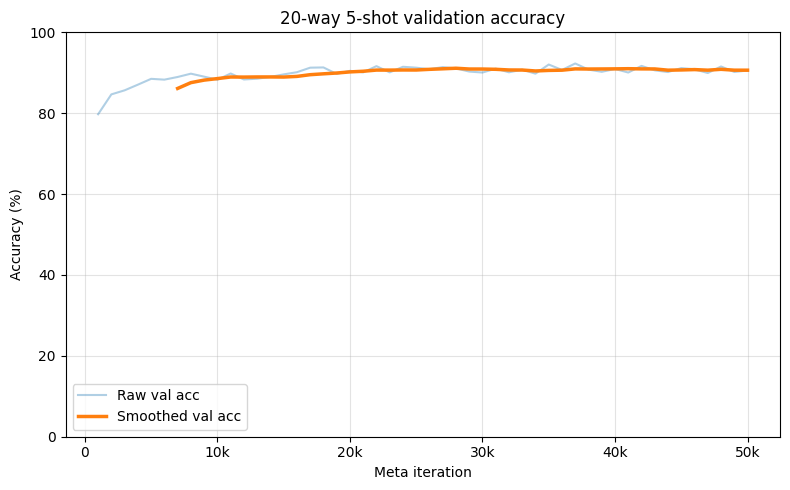

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def moving_average(x, window=20):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

def k_formatter(x, pos):
    if x == 0:
        return "0"
    return f"{x/1000:.0f}k"

eval_points = history_plot["eval_query_accuracies"]
if len(eval_points) > 0:
    eval_iters = np.array([p[0] for p in eval_points])
    eval_accs = np.array([p[1] for p in eval_points])

    smooth_window = min(7, max(1, len(eval_accs)))
    smooth_accs = moving_average(eval_accs, window=smooth_window)
    smooth_iters = eval_iters[smooth_window - 1:]

    plt.figure(figsize=(8, 5))
    plt.plot(eval_iters, eval_accs * 100, alpha=0.35, label="Raw val acc")
    plt.plot(smooth_iters, smooth_accs * 100, linewidth=2.5, label="Smoothed val acc")
    plt.title("20-way 5-shot validation accuracy")
    plt.xlabel("Meta iteration")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
    plt.tight_layout()
    plt.show()
else:
    print("No validation accuracy points yet.")


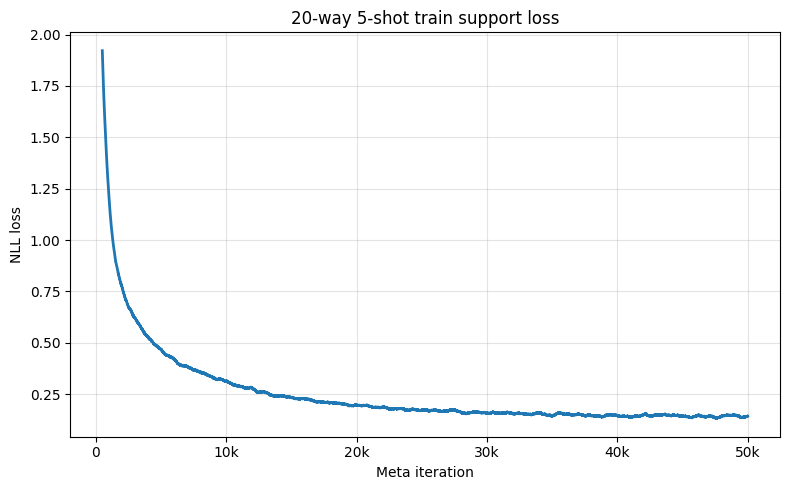

In [20]:

train_losses = np.array(history_plot["train_support_losses"], dtype=float)

if len(train_losses) > 0:
    window = min(500, max(1, len(train_losses)))
    smooth_train = moving_average(train_losses, window=window)
    smooth_x = np.arange(1, len(train_losses) + 1)[window - 1:]

    plt.figure(figsize=(8, 5))
    plt.plot(smooth_x, smooth_train, linewidth=2.0)
    plt.title("20-way 5-shot train support loss")
    plt.xlabel("Meta iteration")
    plt.ylabel("NLL loss")
    plt.grid(True, alpha=0.35)
    plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
    plt.tight_layout()
    plt.show()
else:
    print("No train loss points yet.")


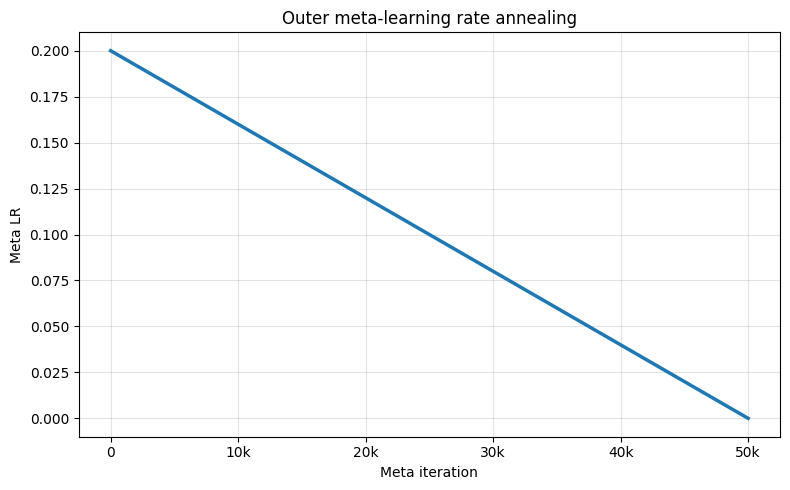

In [21]:

lr_points = history_plot["meta_lr_history"]

if len(lr_points) > 0:
    lr_iters = np.array([p[0] for p in lr_points])
    lrs = np.array([p[1] for p in lr_points])

    plt.figure(figsize=(8, 5))
    plt.plot(lr_iters, lrs, linewidth=2.5)
    plt.title("Outer meta-learning rate annealing")
    plt.xlabel("Meta iteration")
    plt.ylabel("Meta LR")
    plt.grid(True, alpha=0.35)
    plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
    plt.tight_layout()
    plt.show()
else:
    print("No meta-LR history yet.")
